**Punkte**

| Aufgabe 1 | Aufgabe 2 | Aufgabe 3 | Aufgabe 4 |
|-----------|-----------|-----------|-----------|
|           |           |           |           |
|     / 50  |     / 15  |     / 25  |     / 10  |
|           |           |           |           |

Gesamtpunktzahl:

___

# Allgemeine Hinweise zur Klausur 01882 **Data Engineering für Data Science**
> **_NOTE:_**  *Bitte lesen Sie sich diese Hinweise vor der Bearbeitung der Klausur aufmerksam durch.*

- Die **Klausurdauer** beträgt **2 Stunden**.
- Bevor Sie mit der Bearbeitung der Klausuraufgaben beginnen, tragen Sie bitte Ihre(n) **Nachnamen**, Ihre(n) **Vornamen** und Ihre **Matrikelnummer** in die vorgesehenen Felder (oben) ein.
- Wie schon in den Übungsaufgaben erfolgt die Bearbeitung in zwei unterschiedliche Zell-Typen: In **Code-Zellen** sollen Sie (Python-)Code (bei Bedarf kommentiert) einfügen und ausführen. In **Raw-Zellen** erwarten wir eine Antwort in Textform.
- Sollten bestimmte Fakten aus Ihrer Sicht nicht eindeutig formuliert sein, so schreiben Sie Ihre Annahmen zur Lösung dazu.
- Denken Sie bei Plots an Titel, Achsenbeschriftung und bei Bedarf Legende.
- Es empfiehlt sich, das Notebook, bzw. das daraus generierte PDF in regelmäßigen Abständen zu sichern. So müssen Sie nicht bei Null anfangen, sollte es unerwartetere Weise zu Software-Problemen kommen.
- Diese Klausur ist eine sogenannte "Open-Book-Klausur", was bedeutet, dass Sie alle Vorlesungsunterlagen, etc. als Hilfsmittel verwenden dürfen. Es ist jedoch ausdrücklich **verboten**, dass Sie untereinander kommunizieren oder andere Personen zu Rate ziehen. Explizit untersagt ist außerdem die Nutzung von AI-Chatbots wie beispielsweise ChatGPT.
- Es werden nur Lösungsabgaben im PDF-Format akzeptiert. Diese müssen mit der vom Lehrgebiet bereitgestellten Software-Umgebung über `File -> Download as -> PDF via LaTeX (.pdf)` oder dem entsprechenden Konsolenaufruf erzeugt worden sein.


___

In [15]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import iplantuml

<div class="alert alert-block alert-danger">

Diese Zelle bitte auf keinen Fall löschen, da der Seitenumbruch für die Korrektur benötigt wird.
    
\newpage

</div>

## Aufgabe 1 - Datenvorverarbeitung und Datenqualität: Zoo Pixhagen (50 Punkte)
Ein fiktives Szenario: Die Pixschule in Pixhagen (benannt nach dem Gründer der Stadt - Piet Pix) veranstaltet zu Beginn jedes Schuljahres eine Projektwoche. Dieses Jahr ist eine Kooperation mit dem Pixhagener Zoo entstanden. Zu diesem Zweck hat die Zoodirektorin Rhea Hermansen ihre Teamleiter:innen beauftragt, Daten über die Tiere zu erfassen. Die Datenerfassung begann am 1. August 2024 und wurde am 20. August 2024 abgeschlossen. Danach wurde anhand der Daten eine Broschüre erstellt, die die Schulkinder zu Beginn der Projektwoche (1. September 2024) erhalten. 

Die Broschüre ist jedoch noch unvollständig. Die Vervollständigung ist Inhalt dieser Klausur. Zeitpunkt der Analyse ist der heutige Tag.

Folgende Dokumente stehen Ihnen zur Verfügung:
- zoo-pixhagen.csv - Die Daten über die Tiere
- zoo-pixhagen.pdf - Die Broschüre, die den Schulkindern zu Beginn des Ferienprogramms ausgehändigt wird.


### Datenerhebung (8 Punkte)
Zur Datenerfassung schreibt die Zoodirektorin folgende Notiz an die Teamleiter:innen und legt die untenstehende Tabelle bei:
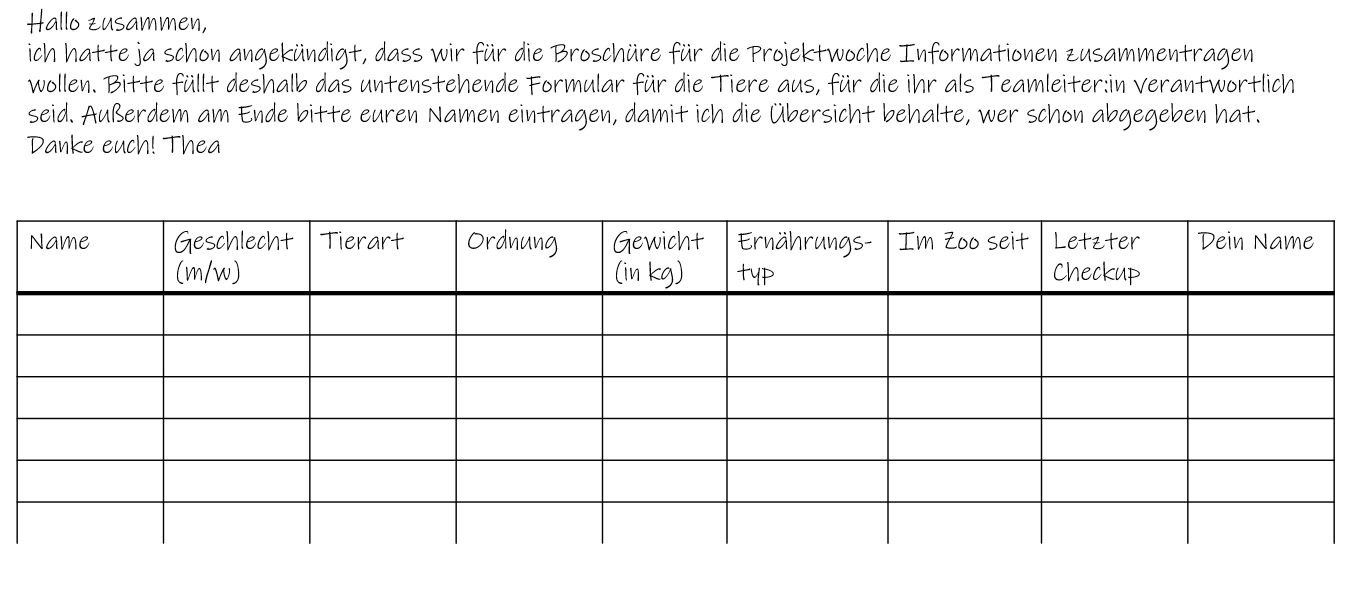


Um sich nochmal abzusichern, fragt sie ChatGPT nach den größten Datenqualitäts-Problemen bei einer manuellen Datenerfassung mit vorgefertigten Spalten. Im Folgenden die Antwort von ChatGPT:

1. **Eingabefehler**: Manuelle Dateneingabe ist anfällig für Tippfehler, Zahlendreher und andere menschliche Fehler. 
2. **Unvollständige Dateneingabe**: Datenerfasser könnten Felder leer lassen oder unvollständig ausfüllen. 
3. **Missverständnisse bei der Nutzung der Spalten**: Datenerfasser könnten die Bedeutung oder den Zweck bestimmter Spalten nicht richtig verstehen oder falsch interpretieren.
4. **Inkonsistente Datenformate**: Unterschiedliche Datenerfasser verwenden möglicherweise verschiedene Formate für dieselben Datentypen.

*Beschreiben Sie für jeden der Punkte, ob es im Kontext von Rheas Datenerhebung zu Problemen kommen könnte:*
- *Sollte ein Punkt Ihrer Meinung nach auf die vorliegende Datenerhebung zutreffen, beschreiben Sie konkret für **eine** Spalte, was passieren könnte.*
- *Beschreiben Sie in diesem Fall außerdem, welche zusätzliche Information für die gewählte Spalte in der Notiz/der Tabelle ergänzt werden sollte. Sollten Ihrer Meinung nach weitere Informationen in der Notiz/der Tabelle nicht ausreichen, schlagen Sie stattdessen **eine** Maßnahme zur Datenerhebung für diesen Punkt vor, um die Datenqualitäts-Probleme zu vermeiden.*

### Daten laden und Qualität einschätzen (7 Punkte)

#### Daten laden (1 Punkt)
*Laden Sie die Daten (`zoo-pixhagen.csv`) in ein DataFrame namens `df`, so dass der Index rein numerisch ist.*

In [16]:
# Ihre Lösung

df = pd.read_csv("klausur/zoo-pixhagen.csv")
df.head()

,name,geschlecht,tierart,ordnung,gewicht,ernaehrung,im_zoo_seit,letzter_checkup,team
0,Ulysses,m,Hausmaus,Rodentia,0.03,herbi,2018-03-14,2024-07-29,Barbara
1,Melvin,m,Pavian,Primates,33.30,o,2023-07-04,2024-07-06,Oswald
2,Scott,m,Tapir,Perissodactyla,167.91,herbi,2005-03-05,2024-07-10,Meggy
3,Barbara,w,Gazelle,Artiodactyla,48.31,h,2005-08-13,2024-05-08,Shaban
4,Ann,w,Stachelschwein,Rodentia,13.81,o,2015-05-04,2024-05-16,Veronika


#### Data Integrity (6 Punkte)
Machen Sie sich mit den Daten vertraut.

*Beurteilen Sie die Daten anhand 3 Kriterien für **Data Integrity** Ihrer Wahl, die Sie im Buch von McGregor in Kapitel 3 auf den Seiten 79 ff. als **Important** kennengelernt haben.*

In [17]:
# Platz für Analysen
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             118 non-null    object 
 1   geschlecht       118 non-null    object 
 2   tierart          118 non-null    object 
 3   ordnung          118 non-null    object 
 4   gewicht          112 non-null    float64
 5   ernaehrung       118 non-null    object 
 6   im_zoo_seit      118 non-null    object 
 7   letzter_checkup  118 non-null    object 
 8   team             118 non-null    object 
dtypes: float64(1), object(8)
memory usage: 8.4+ KB


In [18]:
df.isna().sum()

name               0
geschlecht         0
tierart            0
ordnung            0
gewicht            6
ernaehrung         0
im_zoo_seit        0
letzter_checkup    0
team               0
dtype: int64

In [19]:
df["ernaehrung"].unique()

array(['herbi', 'o', 'h', 'c', 'carni', 'omni', 'insecti'], dtype=object)

In [20]:
df["ernaehrung"] = df["ernaehrung"].replace({"herbi": "h", "omni": "o", "carni": "c", "insecti": "i"})
df["ernaehrung"].unique()

array(['h', 'o', 'c', 'i'], dtype=object)

In [21]:
df[df["ernaehrung"] == "h"].isna().sum()

name               0
geschlecht         0
tierart            0
ordnung            0
gewicht            5
ernaehrung         0
im_zoo_seit        0
letzter_checkup    0
team               0
dtype: int64

In [22]:
df[df["ernaehrung"] == "h"].groupby("tierart")["gewicht"].median()

tierart
Alpaka               70.260
Elefant            4235.375
Esel                213.220
Gazelle              50.410
Giraffe             877.405
Goldhamster           0.160
Hausmaus              0.030
Meerschweinchen       0.810
Pferd               543.570
Tapir               179.440
Yak                1037.165
Zebra               301.895
Name: gewicht, dtype: float64

### Datenvorverarbeitung (15 Punkte)
Diese Aufgabe beschäftigt sich mit der Datenvorverarbeitung.

#### Plausibilitätschecks (6 Punkte)

Entsprechend der Informationen aus der Broschüre sind verschiedene Plausibilitätschecks der Daten denkbar. Bei diesen Checks wird geprüft, ob sich die vorliegenden Informationen in den Daten wiederspiegeln.

*Führen Sie drei Plausibilitätschecks Ihrer Wahl durch. Geben Sie bei jedem Check an, auf welche Information Sie sich beziehen und, ob der Check fehlgeschlagen ist oder nicht.*

In [23]:
# Ihre Lösung

# Prüfung ob alle Tiere einer Tierarten der Broschüre entsprechen
tierarten = df["tierart"].unique()
tierarten.sort()
tierarten

array(['Alpaka', 'Elefant', 'Emu', 'Erdmaennchen', 'Esel',
       'Eulenkopfmeerkatze', 'Gazelle', 'Gepard', 'Giraffe',
       'Goldhamster', 'Hausmaus', 'Husarenaffe', 'Jaguar', 'Katta',
       'Loewe', 'Meerschweinchen', 'Pavian', 'Pferd', 'Riesenguerteltier',
       'Schimpanse', 'Stachelschwein', 'Tapir', 'Tiger', 'Trampeltier',
       'Yak', 'Zebra'], dtype=object)

In [24]:
# Prüfung ob alle Tiere einer Art die selbe Ernährung haben
df.groupby("tierart")["ernaehrung"].nunique()

tierart
Alpaka                1
Elefant               1
Emu                   1
Erdmaennchen          1
Esel                  1
Eulenkopfmeerkatze    1
Gazelle               1
Gepard                1
Giraffe               1
Goldhamster           1
Hausmaus              1
Husarenaffe           1
Jaguar                1
Katta                 1
Loewe                 1
Meerschweinchen       1
Pavian                1
Pferd                 1
Riesenguerteltier     1
Schimpanse            1
Stachelschwein        1
Tapir                 1
Tiger                 1
Trampeltier           1
Yak                   1
Zebra                 1
Name: ernaehrung, dtype: int64

In [25]:
# Prüfung ob alle Tiere am oder nach dem 04.04.2004 in den Zoo gekommen sind
df["im_zoo_seit"].min()

'2004-04-24'

#### Praktische Anwendung (9 Punkte)
Für eine sinnvolle Analyse sind diverse Vorverarbeitungsschritte notwendig. 

*Führen Sie Vorverarbeitungsmaßnahmen durch, die Ihrer Meinung nach nötig sind, um die Qualität der Daten zu verbessern und die nachfolgenden Analysen durchzuführen. Begründen Sie für jede Maßnahme Ihr Vorgehen.*


> **Hinweise**:
> - *Eine **Umbenennung** von Spalten ist nicht notwendig!*
> - *Es sollen keine neuen Spalten **hinzugefügt** werden!*
> - *Es sollen keine Spalten **gelöscht** werden!*
> - *Sollten Sie im Zuge der Qualitätsanalyse oder der Plausibilitätschecks schon Transformationen durchgeführt haben, ergänzen Sie hier bitte einen **Verweis** und geben Sie trotzdem eine entsprechende **Begründung** an.*
> - *Welche Informationen für die Analyse gebraucht werden, können Sie dem Entwurf der Broschüre entnehmen. Spalten, die nicht für die Analyse benötigt werden, können Sie bei den Vorverarbeitungsmaßnahmen vernachlässigen.*

In [26]:
# Ihre Lösung

# Bereits durchgeführt
# df["ernaehrung"] = df["ernaehrung"].replace({"herbi": "h", "omni": "o", "carni": "c", "insecti": "i"})

df["im_zoo_seit"] = pd.to_datetime(df["im_zoo_seit"]).dt.year

### Datenanalyse (20 Punkte)
In dieser Aufgabe sollen die Analysen vorgenommen werden, die für die Broschüre benötigt werden.

#### Allgemein
Es folgen zunächst ein paar allgemeine Analysen, die die für die Broschüre auf den Seiten 7 und 8 benötigt werden. 

##### Anzahl Tiere (4 Punkte) 
- *Erstellen Sie das Säulendiagramm, das in der Broschüre auf Seite 7 benötigt wird.*
- *Berücksichtigen Sie dabei die Kriterien, die Sie im Buch von McGregor in Kapitel 10 auf den Seiten 327 ff. kennengelernt haben: Werden alle Regeln und Richtlinien erfüllt? Falls Nein: Welche sind verletzt?*
- *Mit welcher Tierart muss der Platzhalter \<Tierart\> gefüllt werden?*

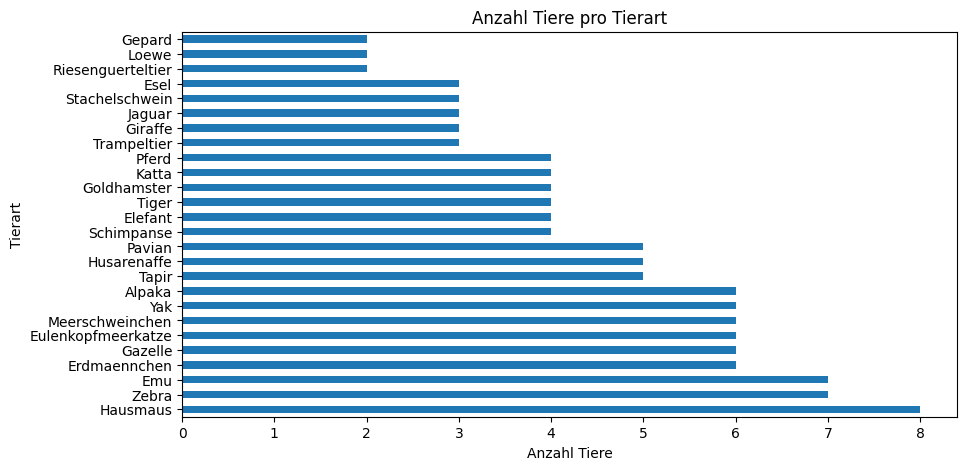

In [27]:
# Ihre Lösung

df['tierart'] \
    .value_counts() \
    .plot.barh(figsize=(10,5), title="Anzahl Tiere pro Tierart", xlabel="Anzahl Tiere", ylabel="Tierart")
plt.show()

##### Zuwachs an Tieren (4 Punkte)
- *Erstellen Sie das Liniendiagramm, das in der Broschüre auf Seite 8 benötigt wird.*
- *Berücksichtigen Sie dabei die Kriterien, die Sie im Buch von McGregor in Kapitel 10 auf den Seiten 327 ff. kennengelernt haben: Werden alle Regeln und Richtlinien erfüllt? Falls Nein: Welche sind verletzt?*
- *In welchem Jahr sind am meisten neue Tiere hinzugekommen?*

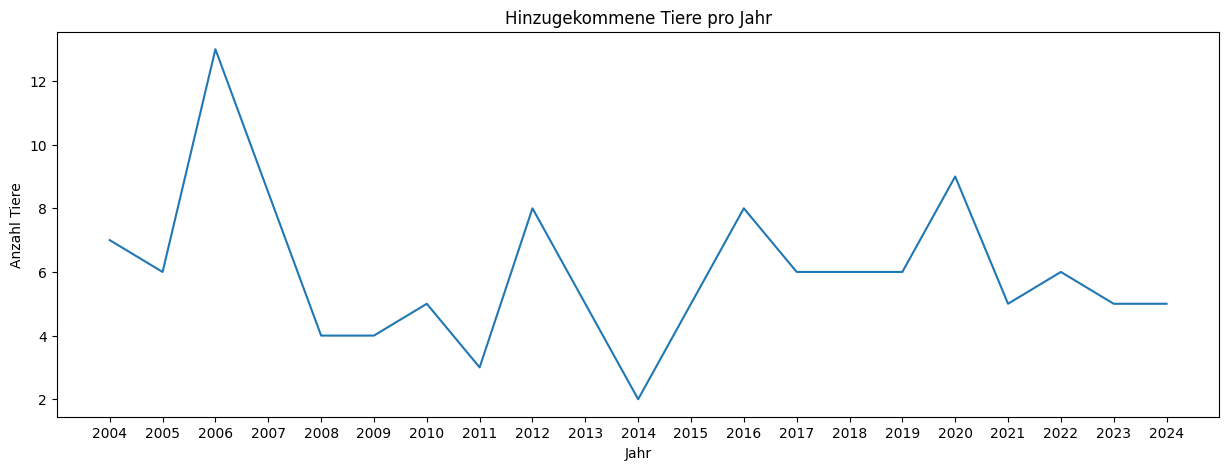

In [33]:
# Ihre Lösung

df["im_zoo_seit"].value_counts().sort_index() \
    .plot(kind="line", figsize=(15,5), title="Hinzugekommene Tiere pro Jahr", xlabel="Jahr", ylabel="Anzahl Tiere", xticks=range(2004, 2025))
plt.show()

#### Im Fokus: Herbivore
Betrachten Sie im Folgenden nur die Herbivore und führen Sie die Analysen durch, die für die Broschüre für die Seiten 10, 11 und 12 benötigt werden.

#####  Leichtestes und schwerstes Tier (4 Punkte)
Auf Seite 10 der Broschüre wird das leichteste und das schwerste Tier der Herbivore gesucht. Geben Sie in der Raw-Zelle alle Informationen an, die für die Steckbriefe benötigt werden.

In [34]:
# Ihre Lösung
df[df["ernaehrung"] == "h"].groupby("tierart")["gewicht"].median().sort_values()

tierart
Hausmaus              0.030
Goldhamster           0.160
Meerschweinchen       0.810
Gazelle              50.410
Alpaka               70.260
Tapir               179.440
Esel                213.220
Zebra               301.895
Pferd               543.570
Giraffe             877.405
Yak                1037.165
Elefant            4235.375
Name: gewicht, dtype: float64

##### Anzahl Tierarten pro Ordnung (4 Punkte)
- *Erstellen Sie die Kreisdiagramme (eines pro Ordnung), die in der Broschüre auf Seite 11 benötigt werden.*
- *Berücksichtigen Sie dabei die Kriterien, die Sie im Buch von McGregor in Kapitel 10 auf den Seiten 327 ff. kennengelernt haben: Werden alle Regeln und Richtlinien erfüllt? Falls Nein: Welche sind verletzt?*
- *Bei welcher Ordnung gibt es am meisten unterschiedliche Tierarten? Sollten mehrere Ordnungen in Frage kommen, geben Sie alle an.*

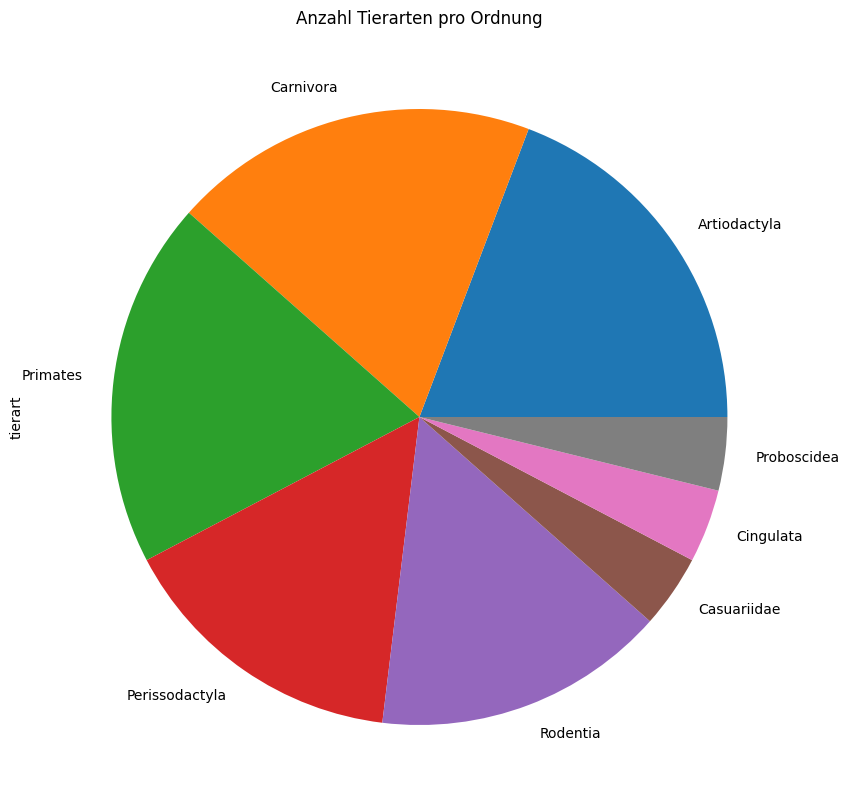

In [38]:
# Ihre Lösung

df.groupby("ordnung")["tierart"].nunique().sort_values(ascending=False) \
    .plot \
    .pie(figsize=(15,10), title="Anzahl Tierarten pro Ordnung")
plt.show()

In [46]:
df.groupby("ordnung")["tierart"].nunique().sort_values(ascending=False)

ordnung
Artiodactyla      5
Carnivora         5
Primates          5
Perissodactyla    4
Rodentia          4
Casuariidae       1
Cingulata         1
Proboscidea       1
Name: tierart, dtype: int64

##### Verhältnis Männchen - Weibchen (4 Punkte)
- *Erstellen Sie das Kreisdiagramm, das in der Broschüre auf Seite 12 benötigt wird.*
- *Berücksichtigen Sie dabei die Kriterien, die Sie im Buch von McGregor in Kapitel 10 auf den Seiten 327 ff. kennengelernt haben: Werden alle Regeln und Richtlinien erfüllt? Falls Nein: Welche sind verletzt?*
- *Gibt es unter den Herbivoren mehr Männchen oder mehr Weibchen im Zoo?*

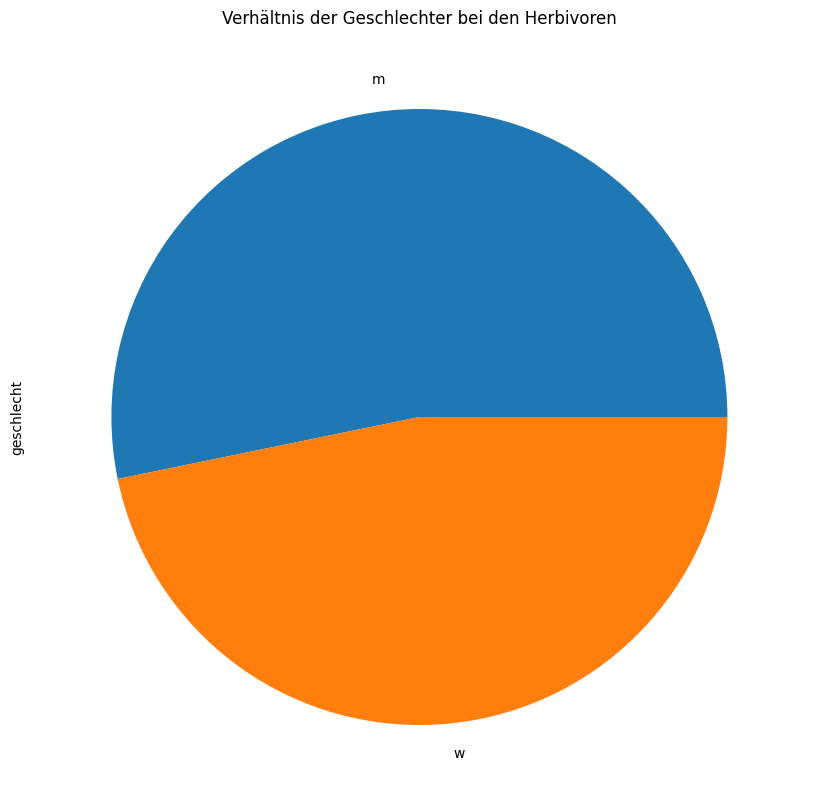

In [48]:
# Ihre Lösung

# Verhältnis der Geschlechter bei den Tieren mit der Ernährung "h"
df[df["ernaehrung"] == "h"]["geschlecht"].value_counts(normalize=True) \
    .plot \
    .pie(figsize=(15,10), title="Verhältnis der Geschlechter bei den Herbivoren")
plt.show()

<div class="alert alert-block alert-danger">

Diese Zelle bitte auf keinen Fall löschen, da der Seitenumbruch für die Korrektur benötigt wird.
    
\newpage

</div>

## Aufgabe 2 - Big Data Analysis (15 Punkte)
In diesem Aufgabenbereich geht es um den Hadoop-Zoo und Spark.

Der Pixhagener Zoo hat eine Kooperation mit dem San Diego Zoo in den USA, einem der größten Zoos der Welt. Diese betreiben für ihre umfangreichen Daten ein Hadoop Cluster. Rhea überlegt, den Pixhagener Zoo mit Sensoren auszustatten, um Daten über Tiere und Besuchendenströme zu sammeln und hierfür evtl. auch ein Hadoop Cluster anzuschaffen. Um ein paar Tests zu machen, bekommt sie Zugriff auf das Testcluster des San Diego Zoos.

### Dateien einlesen (3 Punkte)
Betrachten Sie folgenden Auszug aus Rheas lokalem FS und dem HDFS:
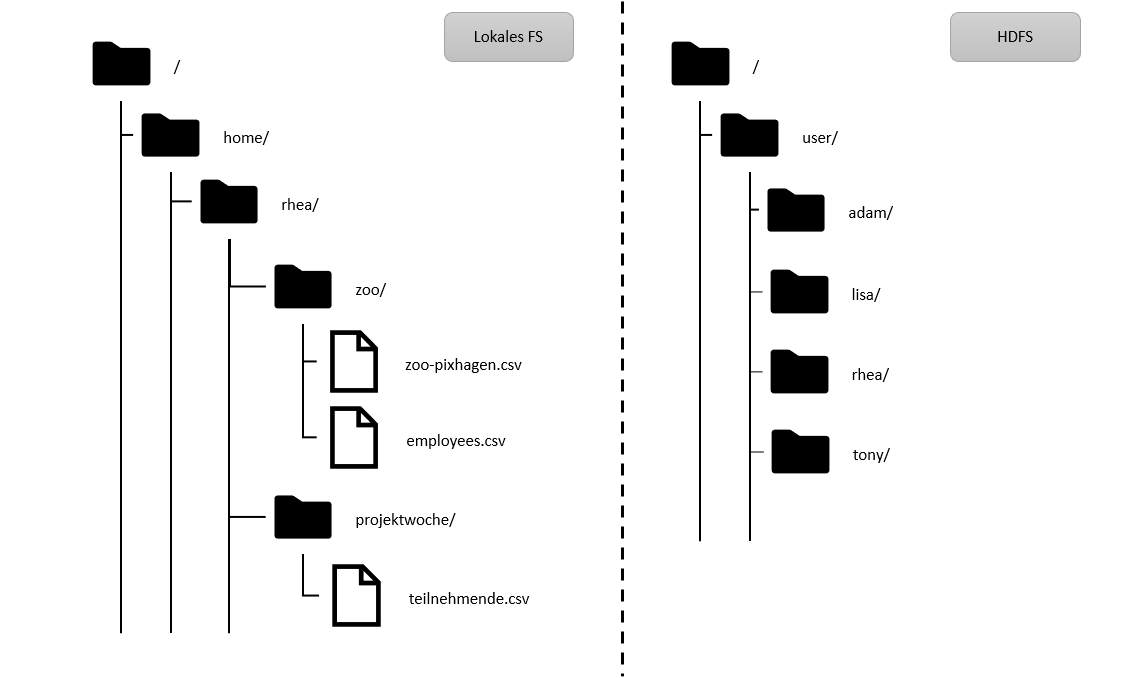

Rhea wurde vom San Diego Zoo die Verbindung zum Testcluster eingerichtet und Code zur Verfügung gestellt, um Daten in das HDFS zu laden:
```python
from hdfs import InsecureClient
client = InsecureClient('http://hadoop-edge:9870', user='rhea')

path1 = ''
path2 = ''
client.upload(path1, path2)
```

Rhea möchte nun die Datei `zoo-pixhagen.csv` aus ihrem lokalen Dateisystem in ihren persönlichen Ordner im HDFS ablegen.

*Welche Pfade muss Rhea für die Variablen `path1` und `path2` angeben? Und warum lädt sie die Daten in das HDFS (eine kurze Antwort ist ausreichend, hier müssen nicht die Vorteile des HDFS aufgezählt werden)?*

### Daten abfragen (2 + 2 Punkte)
Zu Testzwecken betrachtet Rhea nur einen Ausschnitt der Daten und hat dafür exemplarisch zwei Spark Datasets erstellt, die im Folgenden zu sehen sind:

`animals_df`:
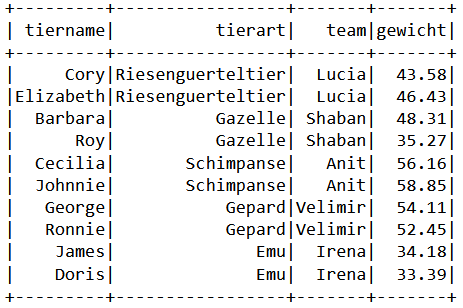


`employees_df`:
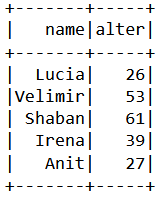

Jetzt führt Sie folgende Abfrage aus (alle benötigten Bibliotheken hat sie bereits importiert):

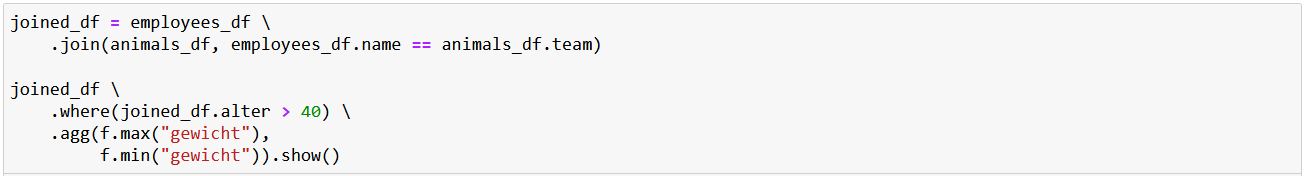

*Was ist das Ergebnis der Abfrage? Schreiben Sie die Werte in die untenstehende Antwortzelle. (2 Punkte)*

Als nächstes möchte sie sich alle Tiernamen ausgeben lassen und führt dafür folgenden Code aus:
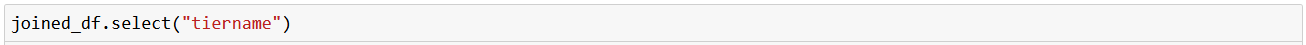

Sie erhält jedoch nicht die Tiernamen, sondern folgende Ausgabe:
```python
>> DataFrame[tiername: string]
```

*Warum werden die Tiernamen nicht ausgegeben? Welches Prinzip von Spark liegt dem zugrunde? (2 Punkte)*

### Ressourcenvebrauch (4 + 4 Punkte)
Um anderen Leuten auf dem Testcluster keine Ressourcen wegzunehmen, wurde Rhea eine eigene Queue eingerichtet, in der ihr folgende Ressourcen zur Verfügung stehen:
- 64GB Memory
- 32 Cores

> *Hinweis: Sie müssen an dieser Stelle nicht im Detail wissen, was eine Queue ist. Wichtig ist nur, dass Rhea die Ressourcen hier exklusiv zur Verfügung stehen (und niemand anderes diese Ressourcen in Anspruch nehmen kann)*

Im Folgenden ist der Inhalt der Datei `spark-defaults.conf` zu sehen:

```
spark.executor.instances 3
spark.executor.memory 16GB
spark.executor.cores 8
spark.executor.memoryOverhead 512MB

spark.yarn.am.cores 2
spark.yarn.am.memory 4GB
spark.yarn.am.memoryOverhead 512MB

spark.dynamicAllocation.enabled false
```

Rhea öffnet ein Jupyter Notebook (bisher hat sie sonst keine weiteren Spark-Applikationen gestartet) und erstellt (nach erfolgreichem Import der benötigten Bibliotheken) mit folgendem Aufruf eine SparkSession:

```python
spark = SparkSession.builder \
    .master("yarn") \
    .appName("Rheas-Tests") \
    .getOrCreate()
```

*Berechnen Sie den Ressourcen-Verbrauch (Memory und Cores) der Spark-Anwendung. Geben Sie dabei Ihren Rechenweg an. (4 Punkte)*

Parallel (während der Kernel des anderen Notebooks weiter läuft) öffnet sie ein weiteres Jupyter Notebook, um neben den Tests mit DataFrames auch mit RDDs herumprobieren zu können und führt (nach erfolgreichen Imports) folgende Notebook-Zelle aus:

```python
spark = SparkSession.builder \
    .master("yarn") \
    .appName("Rheas-Tests") \
    .config("spark.executor.memory", "4GB") \
    .config("spark.executor.cores", "2") \
    .getOrCreate()

sc = spark.sparkContext
```

Die Erstellung der SparkSession dauert jedoch an und wird scheinbar nicht vollendet.

*Wie viele Ressourcen werden benötigt? Kann die Notebook-Zelle zur Erstellung der SparkSession erfolgreich ausgeführt werden? Kann Spark-Code ausgeführt werden? Begründen Sie Ihre Antworten! (4 Punkte)*

<div class="alert alert-block alert-danger">

Diese Zelle bitte auf keinen Fall löschen, da der Seitenumbruch für die Korrektur benötigt wird.
    
\newpage

</div>

## Aufgabe 3 - Modellierung, NoSQL (25 Punkte)

Der Pixhagener Zoo möchte gerne seinen Webauftritt interessanter gestalten und hat daher folgende neue Features geplant:
- Pflegerinnen (Keeper) können Geschichten zu den verschiedenen Tieren schreiben. Die Beliebtheit bei den Lesern kann über den sogenannten *cutie count* dargestellt werden.
- Registrierte Besucherinnen können Kommentare (Reactions) zu den Stories schreiben und den *cutie count* inkrementieren.

Zunächst sollen folgende Funktionen umgesetzt werden:
1. Wird die Seite eines bestimmten Tieres geöffnet, werden neben den verschiedenen Informationen zu dem Tier ebenfalls die beliebteste Story (auf Basis des *cutie counts*), sowie die 3 neuesten *Reactions* zu der Story angezeigt.
2. Es kann eine Liste der 10 neuesten Stories angezeigt werden.
3. Wird eine bestimmte Story geöffnet, werden neben den verschiedenen Informationen der Story ebenfalls die 3 neuesten *Reactions* angezeigt.
4. Pfleger können neue Stories zu den Tieren veröffentlichen.
5. Registrierte Besucherinnen können *Reactions* zu den veröffentlichten Stories schreiben.
6. Registrierte Besucherinnen können den *cutie count* der Stories inkrementieren.

In Folgenden wird der entsprechende Ausschnitt des ersten konzeptionellen Entwurfs des Datenbankschemas sowie eine detaillierte Beschreibung der notwendigen Abfragen bezüglich der zunächst geplanten Funktionen bereitgestellt:

 Ausschnitt des konzeptionellen Schemas:

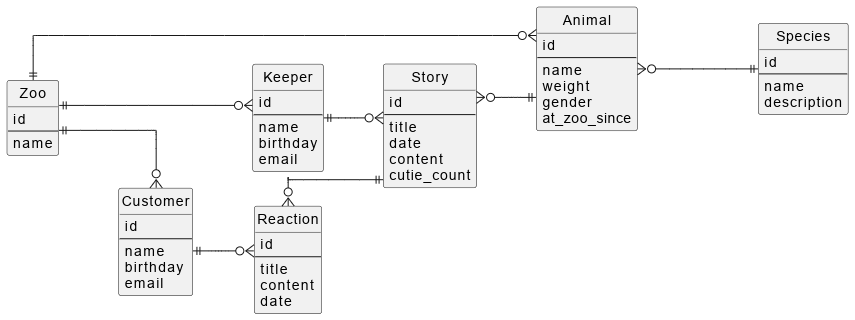

Detaillierte Beschreibung der zunächst benötigten Abfragen:

**Leseoperationen**

- **R1 (Informationen zu einem Tier anzeigen)** 
    - Estimated frequency: 1000 per day
    - Gegeben ist die id eines Tieres (*Animal.id*), gebe folgende Daten aus: 
        - *Animal.name*
        - *Animal.gender*
        - *Animal.at_zoo_since*
        - *Species.name* 
        - *story_count* (Anzahl der Stories zu diesem Tier)
        - *favorite_story* (Beliebteste Story anhand des höchsten cutie count)  
            - *Story.title*
            - *Story.content*
            - *Story.date*
            - *Story.cutie_count*
            - *Keeper.name* (Author der Story)
            - *Animal.name*
            - *Species.name*
            - *Keeper.name* (Author der Story)
            - *latest_reactions* (Die 3 neuesten Reactions zu der Story)
- **R2 (Eine Liste der 10 neuesten Stories)** 
    - Estimated frequency: 1000 per day
    - Gebe folgende Daten der 10 neuesten Stories aus:
        - *Story.title*
        - *Story.date*
        - *Story.cutie_count*
        - *Animal.name*
        - *Species.name*
- **R3 (Eine bestimmte Story anzeigen)** 
    - Estimated frequency: 2500 per day
    - Gegeben ist die id einer Story (*Story.id*), gebe folgende Daten aus:
        - *Story.title*
        - *Story.content*
        - *Story.date*
        - *Story.cutie_count*
        - *Animal.name*
        - *Species.name*
        - *Keeper.name* (Author der Story)
        - *latest_reactions* (Die 3 neuesten Reactions zu der Story)




**Schreiboperationen**

- **W1 (Eine neue Story veröffentlichen)** 
    - Estimated frequency: 5 per day
    - Füge eine neue Story anhand folgender gegebener Daten hinzu: 
        - *Keeper.id*
        - *Keeper.name*
        - *Animal.id*
        - *Animal.name*
        - *Species.id*
        - *Species.name*
        - *Story.title*
        - *Story.content*
        - *Story.date*
- **W2 (Eine neue Reaction zu einer Story veröffentlichen)** 
    - Estimated frequency: 50 per day
    - Füge eine Reaction zu einer Story anhand folgender gegebener Daten hinzu: 
        - *Customer.id*
        - *Customer.name*
        - *Story.id*
        - *Reaction.title*
        - *Reaction.content*
        - *Reaction.date*
- **W3 (Cutie count inkrementieren)** 
    - Estimated frequency: 500 per day
    - Gegeben sind die Daten einer bestimmten Story. Inkrementiere folgendes Attribute um 1: 
        - *Story.cutie_count*



### Aufgabe 3.1 (15 Punkte)

Geplant ist die Verwendung eines Document Stores (MongoDB).
Es liegen 4 verschiedene Schemaentwürfe für MongoDB vor. Hier gilt es nun das am besten geeignetste Schema auszuwählen.

<div class="alert alert-block alert-info">
    
Beschreiben Sie zu jedem der 4 nachfolgenden Schemavorschläge mögliche Nachteile (bezüglich der 6 Abfragen) und wählen anschließend das am besten geeignetste Schema mit einer kurzen Begründung aus.

HINWEISE: Indexe können vernachlässigt werden. 
</div>


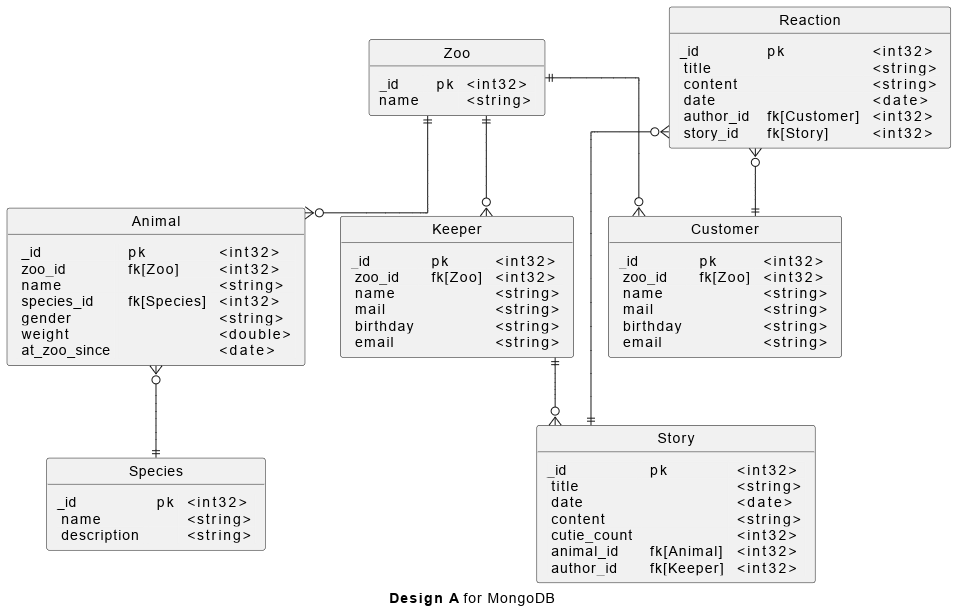

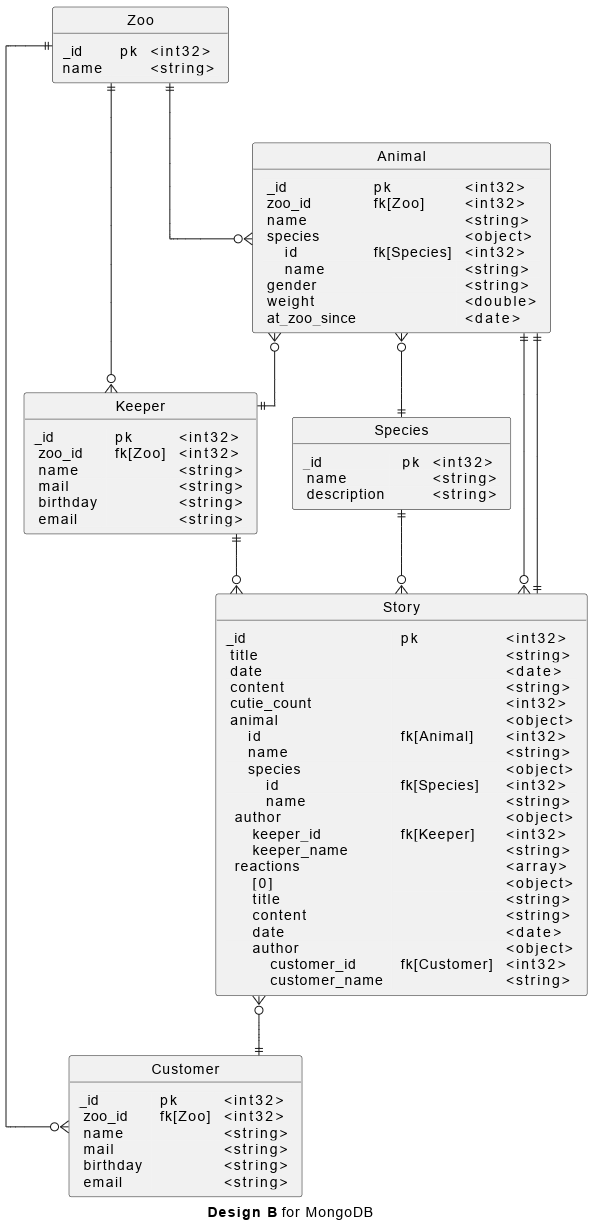

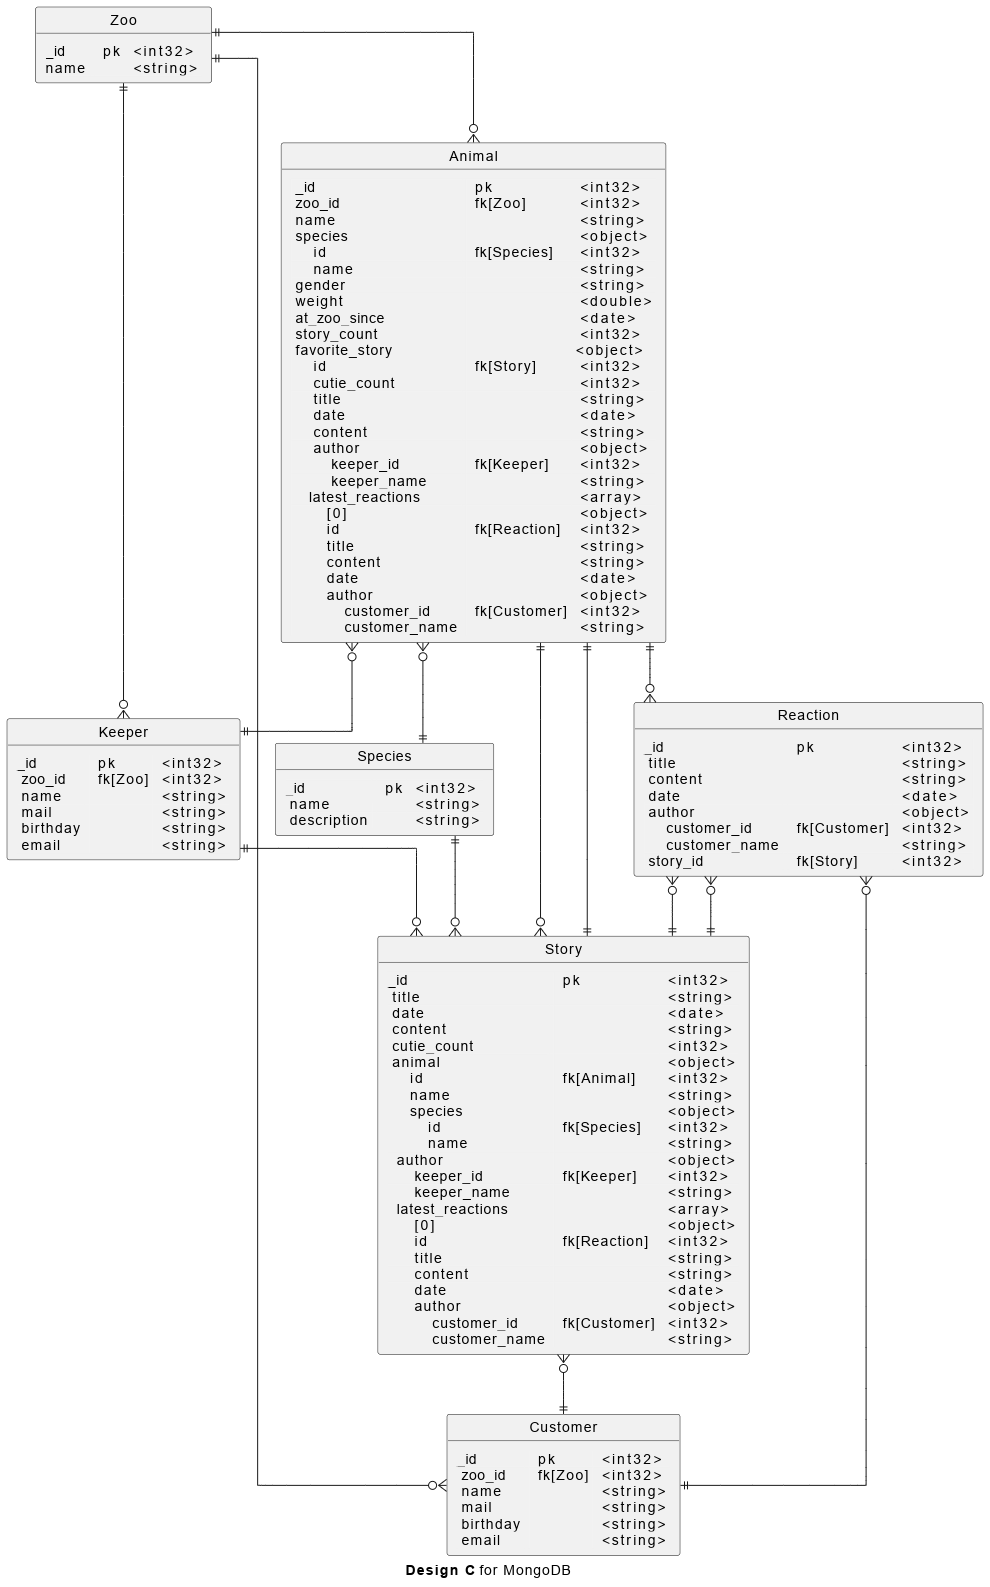

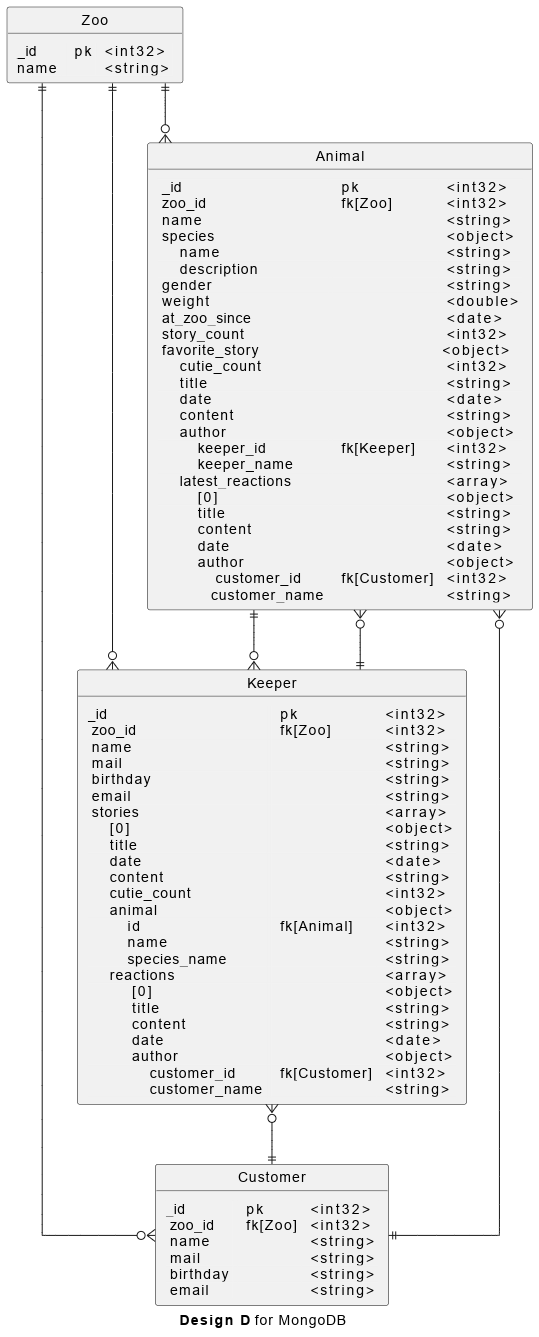

### Aufgabe 3.2 (6 Punkte)

Die Umsetzung der Abfragen für MongoDB wurde von einer externen Firma durchgeführt. Leider fehlt zu manchen Abfragen die Dokumentation.


<div class="alert alert-block alert-info">
    
Beschreiben Sie die Funktion der nachfolgenden Abfragen.
</div>


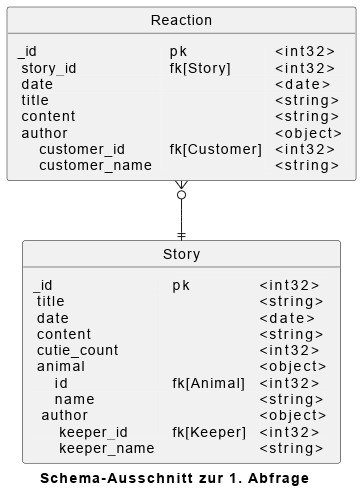

1. Abfrage:

```js
db.Reaction.aggregate([
    {"$match": {"story_id": "<ID OF A STORY>"}},
    { "$sort": { "date": -1 } },
    {"$limit": 3},
    {
        "$group":{
            "_id": "$story_id",
            "latest_reactions": {
                "$push":{
                    "id":"$_id",
                    "date":"$date",
                    "author":"$author",
                    "title":"$title",
                    "content":"$content"
                }
            }
        }
    },
    {
        "$merge": {
            "into": "Story",
            "on": "_id",
        }
    }
]);
```

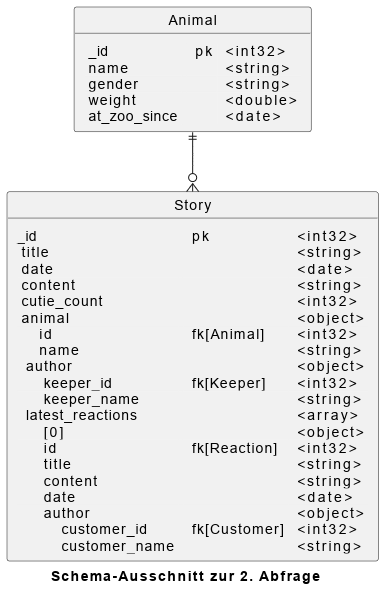

2. Abfrage:

```js
db.Story.aggregate([
    { "$match": { "animal.id": "ID OF AN ANIMAL" }},
    { "$sort": { "cutie_count": -1 } },
    { "$limit": 1 },
    {
        "$group":{
            "_id": "$animal.id",
            "favorite_story": {
                "$first": "$$ROOT"
            }
        }
    },
    {
        "$project": {
            "favorite_story.id": "$favorite_story._id",
            "favorite_story.cutie_count": "$favorite_story.cutie_count",
            "favorite_story.date": "$favorite_story.date",
            "favorite_story.author": "$favorite_story.author",
            "favorite_story.title": "$favorite_story.title",
            "favorite_story.content": "$favorite_story.content",
            "favorite_story.latest_reactions": "$favorite_story.latest_reactions"
        }
    },
    {
        "$merge": {
            "into": "Animal",
            "on": "_id",
        }
    }
]);
```

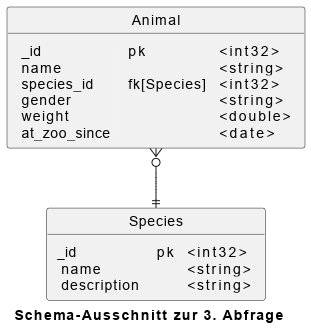

3. Abfrage:

```js
db.Animal.aggregate([
    {
        "$lookup": {
            "from": "Species",
            "localField": "species_id",
            "foreignField": "_id",
            "as": "species"
        }
    },
    {
        "$unwind": "$species"
    },
    {
        "$group": {
            "_id": "$species.name",
            "count": { "$sum": 1 }
        }
    },
    {
        "$project": {
            "species": "$_id",
            "count": 1,
            "_id": 0
        }
    },
    {
        "$sort": { "count": -1 }
    }
]);
```

### Aufgabe 3.3 (2 Punkte)



<div class="alert alert-block alert-info">
    
Bezüglich der Kardinalät einer Beziehung muss bei der Richtung der Einbettung ebenfalls berücksichtigt werden, ob eine vollständige Einbettung, also ohne Erzeugung von Redundanz, möglich ist bzw. zu Problemen führen kann. Was gilt bei folgendem Beispiel bezüglich Einbettungsrichtung zu beachten, wenn davon ausgegangen wird, dass Tiere aus der Datenbank gelöscht werden können?
</div>

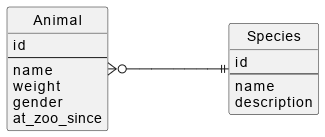

### Aufgabe 3.4 (2 Punkte)



<div class="alert alert-block alert-info">
    
Was gilt im folgenden Beispiel bezüglich Einbettungsrichtungen zu beachten?
</div>

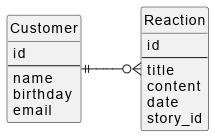

<div class="alert alert-block alert-danger">

Diese Zelle bitte auf keinen Fall löschen, da der Seitenumbruch für die Korrektur benötigt wird.
    
\newpage

</div>

## Aufgabe 4 - Technologien für Big Data (10 Punkte)

Der Pixhagener Zoo soll um ein Reptilienhaus erweitert werden. Dieses soll aus aus drei Räumen mit unzähligen Terrarien bestehen, in denen unterschiedliche Reptilien leben werden. Die Terrarien sollen mit verschiedenen Sensoren ausgestattet werden. Die konstante Messung und Anpassung von Temperatur und Luftfeuchtigkeit sind essentiell, um gute Lebensbedingungen für alle Tiere zu gewährleisten. Vor allem in der Brutzeit, also wenn die Tiere Eier gelegt haben, ist die Temperatur ein entscheidender Faktor. Nur wenn diese stimmt, können die Reptilien in den Eiern gesund heranwachsen. Dementsprechend werden diese Informationen häufig aus dem zugehörigen Datenbanksystem abgefragt, sowohl durch Tierpfleger:innen, als auch automatisiert beispielsweise vom Heizregelsystem.

### Aufgabe 4.1 (4 Punkte)
Für die Speicherung der Daten aus dem Reptilienhaus soll ein spaltenorientiertes Datenbanksystem verwendet werden. Die folgende Abbildung zeigt einen Ausschnitt beispielhafter Daten.

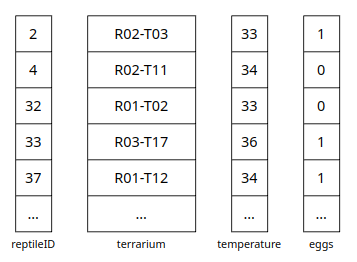

- *reptileID* (int, aufsteigend sortiert) ist die eindeutige ID für ein spezifisches Tier
- *terrarium* (string) ist eine Kodierung, die den Raum (R) und das Terrarium (T) angibt
- *temperature* (int) gibt die Temperatur im Terrarium an
- *eggs* (int) gibt an, ob Eier im Terrarium sind (1) oder nicht (0)

Geben Sie für jede Spalte an, ob und wenn ja, welche Art von Kompression geeignet wäre, um den benötigten Speicherplatz zu minimieren. Begründen Sie ihre Auswahl.

### Aufgabe 4.2 (6 Punkte)
Bei der Planung des Systems fällt auf, dass es eine Query gibt, die besonders häufig ausgeführt werden wird. Entsprechend ist es wichtig, dass diese QUery besonders effizient verarbeitet wird.

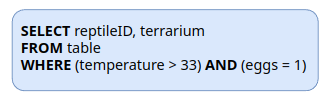

Ein Mitarbeiter des Datenbankteams erstellt folgende schematische Darstellung, für einen möglichen Verarbeitungsablauf.

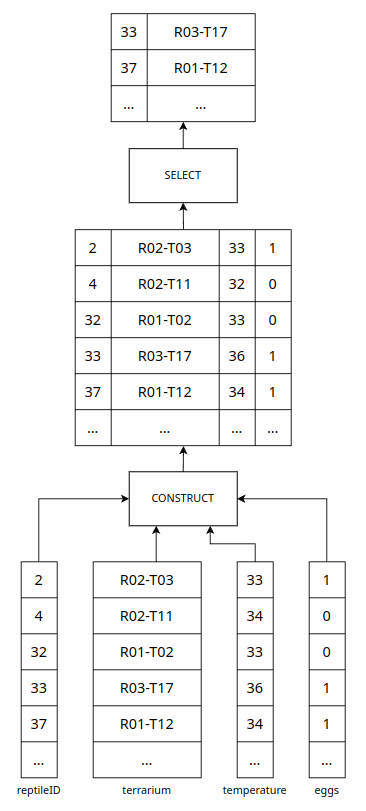

Wie kann der Verarbeitungsablauf durch das Datenbanksystem verbessert werden? Beschreiben Sie schrittweise, wie der optimierte Ablauf aussehen würde. Nutzen Sie dabei die Ergebnisse der letzten Aufgabe, insofern sich dies anbietet.